In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
!unzip '/content/drive/MyDrive/Colab Notebooks/experience 2.zip'

Streaming output truncated to the last 5000 lines.
  inflating: experience 2/Group G/Qaf_Start/AHCR_00043_Qaf_Start_26.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00043_Qaf_Start_27.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00044_Qaf_Start_18.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00044_Qaf_Start_19.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00044_Qaf_Start_26.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00044_Qaf_Start_27.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00045_Qaf_Start_18.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00045_Qaf_Start_19.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00045_Qaf_Start_26.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00045_Qaf_Start_27.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00046_Qaf_Start_18.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00046_Qaf_Start_19.jpg  
  inflating: experience 2/Group G/Qaf_Start/AHCR_00046_Qaf_St

In [18]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 2"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2121/2121 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.4247 - loss: 1.4505 - val_accuracy: 0.7545 - val_loss: 0.6756
Epoch 2/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.7286 - loss: 0.7640 - val_accuracy: 0.7720 - val_loss: 0.6399
Epoch 3/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.7804 - loss: 0.6231 - val_accuracy: 0.8490 - val_loss: 0.4309
Epoch 4/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8061 - loss: 0.5564 - val_accuracy: 0.8505 - val_loss: 0.4346
Epoch 5/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.8253 - loss: 0.5080 - val_accuracy: 0.8647 - val_loss: 0.3931
Epoch 6/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8272 - loss: 0.5000 - val_accuracy: 0.8763 - val_loss: 0.3522
Epoch 7/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8379 - loss: 0.4677 - val_accuracy: 0.8757 - val_loss: 0.3772
Epoch 8/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8433 - loss: 0.45

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9118 - loss: 0.2617
Train Accuracy: 87.31%
Test Accuracy: 90.90%


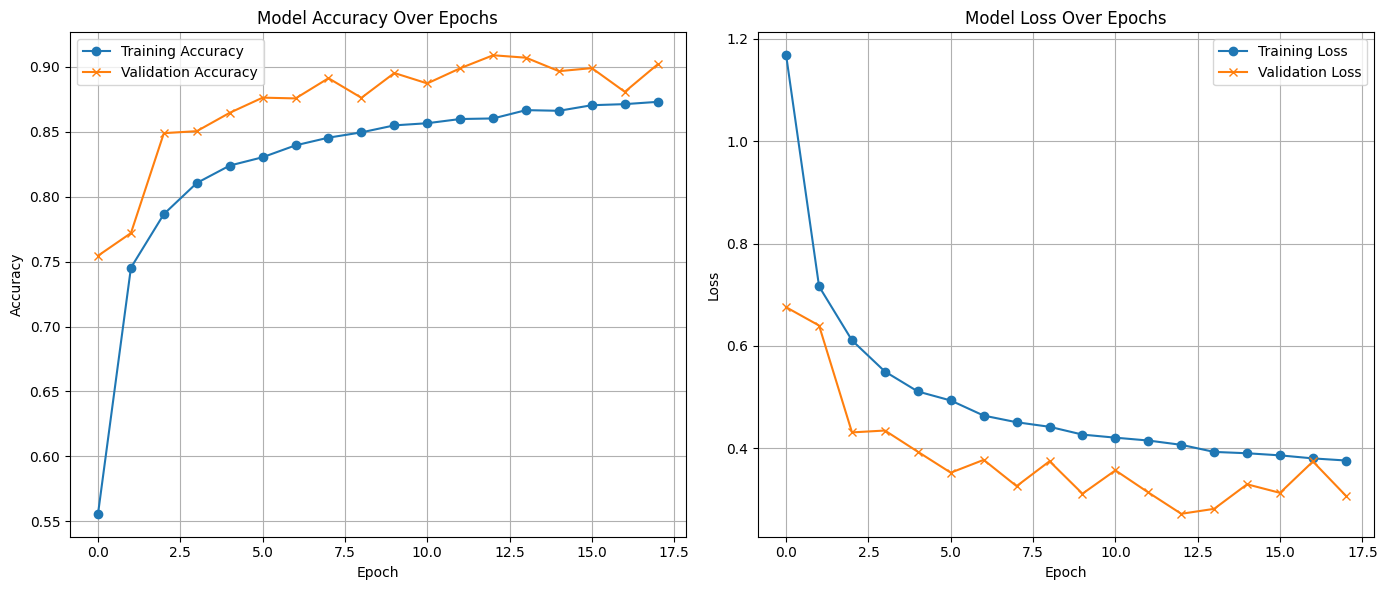

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


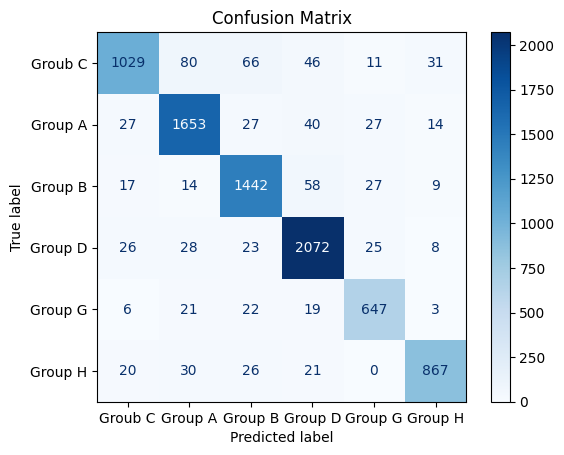

In [19]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

increase Batch size
decrease DropOut

In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 2"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step - accuracy: 0.4642 - loss: 1.3773 - val_accuracy: 0.7285 - val_loss: 0.8173
Epoch 2/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.7424 - loss: 0.7272 - val_accuracy: 0.8341 - val_loss: 0.4783
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.8033 - loss: 0.5655 - val_accuracy: 0.8486 - val_loss: 0.4294
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.8272 - loss: 0.4952 - val_accuracy: 0.8813 - val_loss: 0.3570
Epoch 5/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8470 - loss: 0.4413 - val_accuracy: 0.8803 - val_loss: 0.3505
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8565 - loss: 0.4113 - val_accuracy: 0.8901 - val_loss: 0.3211
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.8659 - loss: 0.3919 - val_accuracy: 0.8762 - val_loss: 0.3673
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.8729 - loss: 0.36

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9072 - loss: 0.2612
Train Accuracy: 89.64%
Test Accuracy: 90.87%


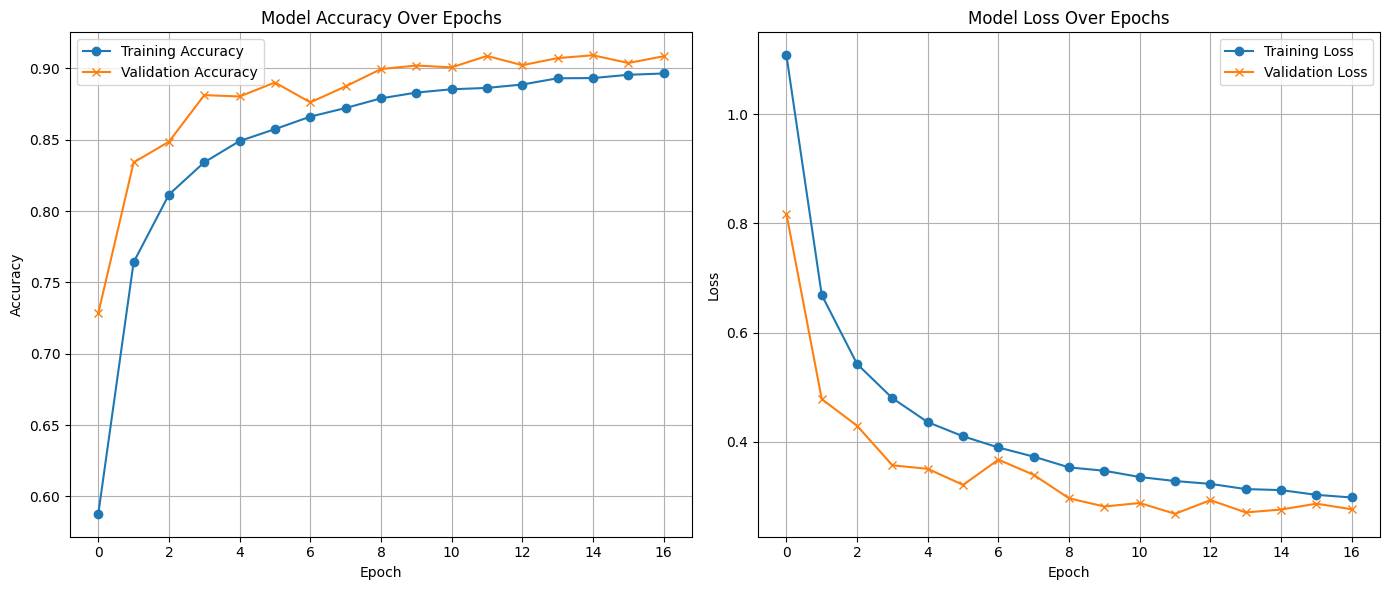

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


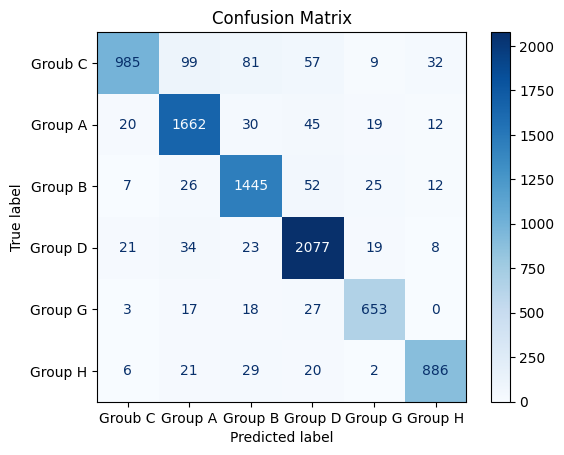

In [22]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### Delete DropOut

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1373/1373 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.4502 - loss: 1.4612 - val_accuracy: 0.7400 - val_loss: 0.7312
Epoch 2/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 77s 31ms/step - accuracy: 0.7473 - loss: 0.7252 - val_accuracy: 0.8142 - val_loss: 0.5327
Epoch 3/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8020 - loss: 0.5767 - val_accuracy: 0.8490 - val_loss: 0.4500
Epoch 4/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8224 - loss: 0.5146 - val_accuracy: 0.8663 - val_loss: 0.3896
Epoch 5/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.8440 - loss: 0.4502 - val_accuracy: 0.8294 - val_loss: 0.5118
Epoch 6/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8479 - loss: 0.4352 - val_accuracy: 0.8868 - val_loss: 0.3383
Epoch 7/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8589 - loss: 0.4098 - val_accuracy: 0.8770 - val_loss: 0.3431
Epoch 8/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.8676 - loss: 0.37

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9042 - loss: 0.2901
Train Accuracy: 89.63%
Test Accuracy: 90.68%


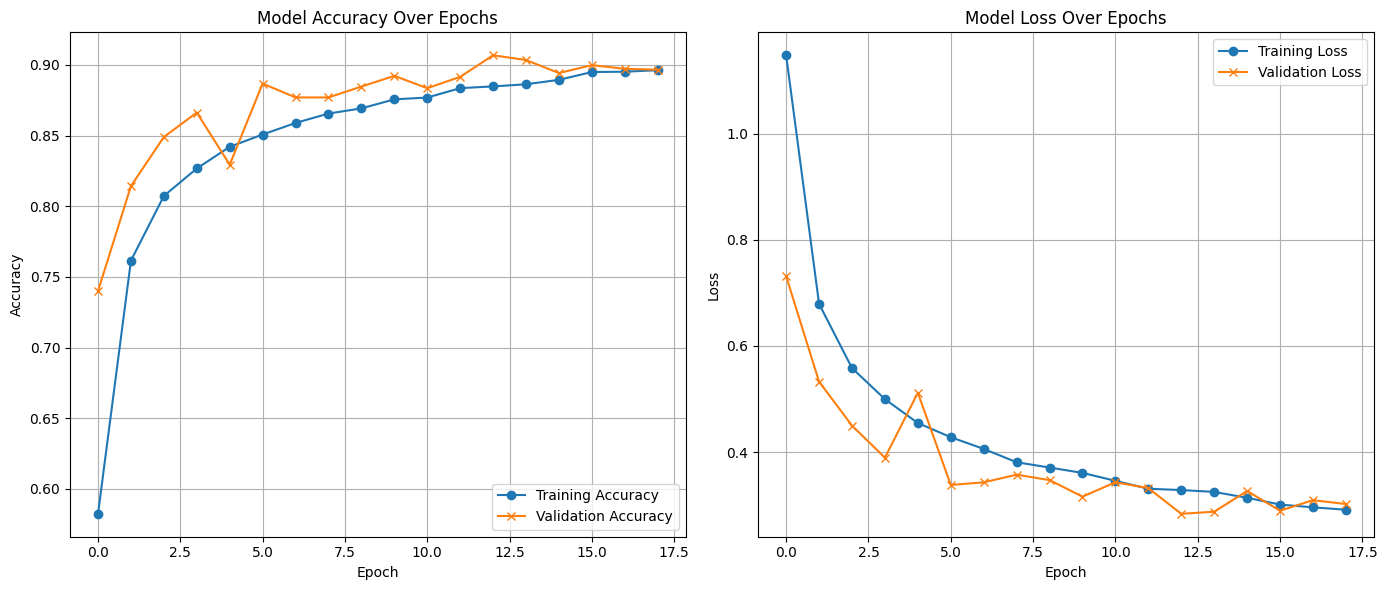

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


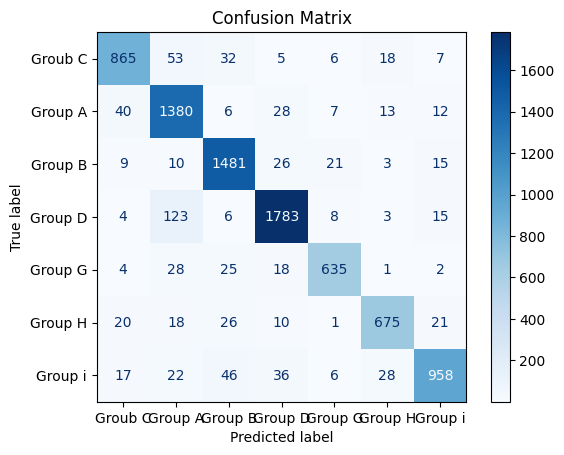

In [3]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [4]:
model.save('cnn2_model.keras')


In [6]:
import os
data_dir = "/content/experience 2"
def count_images(data_dir):
    group_counts = {}
    for group_name in sorted(os.listdir(data_dir)):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
           total_images = 0
           for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    num_images = len(os.listdir(subfolder_path))
                    total_images += num_images
                    print(f"num of pic{group_name}/{subfolder}: {num_images}")
                    group_counts[group_name] = total_images
    return group_counts

group_counts = count_images(data_dir)
print("\nTotal number:", group_counts)

num of picGroub C/Mem_Start: 465
num of picGroub C/Zin_End: 464
num of picGroub C/Zal_Isolated: 474
num of picGroub C/Dal_Isolated: 472
num of picGroub C/Raa_Isolated: 476
num of picGroub C/Mem_End: 467
num of picGroub C/Raa_End: 475
num of picGroub C/Zin_Isolated: 479
num of picGroub C/Dal_End: 480
num of picGroub C/Waw_Isolated: 464
num of picGroub C/Waw_End: 456
num of picGroub C/Zal_End: 476
num of picGroub C/Mem_Isolated: 468
num of picGroup A/Yaa_Dot_End: 464
num of picGroup A/Taa_Isolated: 467
num of picGroup A/Thaa_End: 475
num of picGroup A/Taa_Middle: 462
num of picGroup A/Baa_Start: 473
num of picGroup A/Taa_End: 469
num of picGroup A/Thaa_Isolated: 457
num of picGroup A/Taa_Start: 471
num of picGroup A/Non_Isolated: 466
num of picGroup A/Thaa_Middle: 467
num of picGroup A/Baa_End: 467
num of picGroup A/Thaa_Start: 480
num of picGroup A/Yaa_Dot_Start: 460
num of picGroup A/Baa_Middle: 460
num of picGroup A/Non_Start: 468
num of picGroup A/Yaa_Dot_Isolated: 464
num of picGrou